# **Final Model and Risk Classification**

**Purpose**
- Train the final dengue risk prediction model and generate yearly and overall risk classifications for municipalities.

**Dataset**
- Processed CALABARZON dengue dataset with climate, socioeconomic, and environmental variables.

**Process**
- Load the prepared dataset.
- Train the full model using climate, socioeconomic, and environmental features.
- Classify dengue risk levels using overall 2020–2024 incidence cutoffs.
- Generate yearly risk classifications.
- Apply SHAP analysis to examine feature importance.

**Output**
- Final dengue risk classifications and feature importance results for dashboard visualization.

In [9]:
# =============================
# Import Libraries
# =============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [11]:
# =============================
# Load Dataset
# =============================
DATA_PATH = "/Users/alexandrasantos/Downloads/Thesis_Dataset_Processed (Final).xlsx"
df = pd.read_excel(DATA_PATH)

Full Model (Climate + Socioeconomic + Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 26)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7965
Best params: {'subsample': 0.75, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 6, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}

Hold-out accuracy: 0.8206

Classification report:
              precision    recall  f1-score   support

        High     0.7193    0.4184    0.5290        98
         Low     0.8683    0.9417    0.9035      1183
      Medium     0.6480    0.5474    0.5934       380

    accuracy                         0.8206      1661
   macro avg     0.7452    0.6358    0.6753      1661
weighted avg     0.8091    0.8206    0.8105      1661



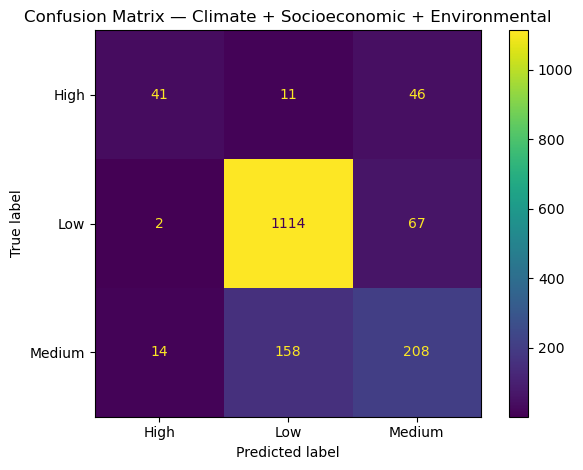

In [13]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"
MUNI_COL = "Municipality"   # <-- needed for final aggregation

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL, MUNI_COL] + CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Keep a copy of municipality/year/month for later reporting
meta = df[[MUNI_COL, "Year", "Month"]].copy()

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns
numeric_cols = [
    # climate
    "Rain", "Temperature", "Relative Humidity",
    # socio numeric
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    # env numeric
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    # time
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model (Climate + Socioeconomic + Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# XGBoost + Hyperparameter Tuning
# -----------------------------
objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
eval_metric = "mlogloss" if num_classes > 2 else "logloss"

base_model = XGBClassifier(
    objective=objective,
    eval_metric=eval_metric,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 2, 4, 6, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation (Hold-out)
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Climate + Socioeconomic + Environmental")
plt.tight_layout()
plt.show()

In [63]:
# ============================================================
# YEARLY CLASSIFICATION USING OVERALL (2020–2024) CUTOFFS
# High = overall 75th percentile of HighRate
# Medium = overall 60th percentile of MedOrHighRate among non-high
# ============================================================

MUNI_COL = "Municipality"

# --- A) Overall (2020–2024) municipality rates ---
overall_summary = (
    df_all_pred.groupby(MUNI_COL)
    .agg(
        Months=("Predicted Risk Level", "size"),
        HighMonths=("Predicted Risk Level", lambda s: (s == "High").sum()),
        MediumMonths=("Predicted Risk Level", lambda s: (s == "Medium").sum()),
        LowMonths=("Predicted Risk Level", lambda s: (s == "Low").sum()),
    )
    .reset_index()
)

overall_summary["HighRate"] = overall_summary["HighMonths"] / overall_summary["Months"]
overall_summary["MedOrHighRate"] = (overall_summary["HighMonths"] + overall_summary["MediumMonths"]) / overall_summary["Months"]

HIGH_RATE_CUTOFF = overall_summary["HighRate"].quantile(0.75)

tmp = overall_summary[overall_summary["HighRate"] < HIGH_RATE_CUTOFF]
MEDORHIGH_CUTOFF = tmp["MedOrHighRate"].quantile(0.60)

print("OVERALL cutoffs (used for every year):")
print("HighRate 75th:", round(HIGH_RATE_CUTOFF, 6))
print("MedOrHighRate 60th (non-high):", round(MEDORHIGH_CUTOFF, 6))

# --- B) Apply those same cutoffs to each year ---
yearly_list = []

for yr, grp in df_all_pred.groupby("Year"):
    yr_summary = (
        grp.groupby(MUNI_COL)
        .agg(
            Months=("Predicted Risk Level", "size"),
            HighMonths=("Predicted Risk Level", lambda s: (s == "High").sum()),
            MediumMonths=("Predicted Risk Level", lambda s: (s == "Medium").sum()),
            LowMonths=("Predicted Risk Level", lambda s: (s == "Low").sum()),
        )
        .reset_index()
    )

    yr_summary["HighRate"] = yr_summary["HighMonths"] / yr_summary["Months"]
    yr_summary["MedOrHighRate"] = (yr_summary["HighMonths"] + yr_summary["MediumMonths"]) / yr_summary["Months"]

    def final_risk(row):
        if row["HighRate"] >= HIGH_RATE_CUTOFF:
            return "High"
        elif row["MedOrHighRate"] >= MEDORHIGH_CUTOFF:
            return "Medium"
        else:
            return "Low"

    yr_summary["Final Risk Level"] = yr_summary.apply(final_risk, axis=1)
    yr_summary["Year"] = yr

    yearly_list.append(yr_summary)

yearly_risk_fixed = pd.concat(yearly_list, ignore_index=True)

print("\nYearly counts (using fixed overall cutoffs):")
print(
    yearly_risk_fixed.groupby("Year")["Final Risk Level"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["High", "Medium", "Low"], fill_value=0)
)

OVERALL cutoffs (used for every year):
HighRate 75th: 0.066667
MedOrHighRate 60th (non-high): 0.216667

Yearly counts (using fixed overall cutoffs):
Final Risk Level  High  Medium  Low
Year                               
2020                11       7  120
2021                 2      26  100
2022                54      48   38
2023                21      46   74
2024                75      46   19


In [67]:
# ============================================================
# SAVE RESULTS FOR DASHBOARD
# ============================================================

OUTPUT_FILE = "/Users/alexandrasantos/Downloads/Dengue_Municipality_Risk_Classification.xlsx"

# Also compute overall classification table
def overall_final(row):
    if row["HighRate"] >= HIGH_RATE_CUTOFF:
        return "High"
    elif row["MedOrHighRate"] >= MEDORHIGH_CUTOFF:
        return "Medium"
    else:
        return "Low"

overall_summary["Final Risk Level"] = overall_summary.apply(overall_final, axis=1)
overall_summary["Year"] = "2020-2024"

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    yearly_risk_fixed.to_excel(writer, sheet_name="Yearly_Risk", index=False)
    overall_summary.to_excel(writer, sheet_name="Overall_Risk_2020_2024", index=False)

print("\nFile saved to:", OUTPUT_FILE)


File saved to: /Users/alexandrasantos/Downloads/Dengue_Municipality_Risk_Classification.xlsx


In [59]:
import pandas as pd
import numpy as np

# ==============================
# SETTINGS
# ==============================
TOP_N_OVERALL = 10
TOP_N_PER_GROUP = 10
OUTFILE = "/Users/alexandrasantos/Downloads/Feature_Importance_Dashboard_CALABARZON.xlsx"

# ==============================
# 1) Get XGBoost Gain Importance
# ==============================
booster = best_model.get_booster()
gain_dict = booster.get_score(importance_type="gain")

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Gain": [gain_dict.get(f, 0.0) for f in X.columns]
})

feat_imp = feat_imp[~feat_imp["Feature"].isin(["Month", "Year"])].copy()

# ==============================
# 2) Define groups (based on your thesis variables)
# ==============================
CLIMATE_BASE = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_BASE = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_BASE = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

def assign_group(feature_name: str) -> str:
    # Climate features usually remain as-is (not one-hot)
    if feature_name in CLIMATE_BASE:
        return "Climate"

    # Socioeconomic one-hot expansions (e.g., "Municipal Class_...")
    if any(feature_name == b or feature_name.startswith(b + "_") for b in SOCIO_BASE):
        return "Socioeconomic"

    # Environmental one-hot expansions (e.g., "Flood Hazard Level_...")
    if any(feature_name == b or feature_name.startswith(b + "_") for b in ENV_BASE):
        return "Environmental"

    return "Other"

feat_imp["Group"] = feat_imp["Feature"].apply(assign_group)

# Keep only the 3 groups (optional but recommended for dashboard clarity)
feat_imp_3 = feat_imp[feat_imp["Group"].isin(["Climate", "Socioeconomic", "Environmental"])].copy()

# ==============================
# 3) Top 10 Overall (across the 3 groups)
# ==============================
top10_overall = (
    feat_imp_3.sort_values("Gain", ascending=False)
    .head(TOP_N_OVERALL)
    .reset_index(drop=True)
)
top10_overall["OverallRank"] = np.arange(1, len(top10_overall) + 1)

# Reorder columns nicely
top10_overall = top10_overall[["OverallRank", "Feature", "Group", "Gain"]]

print("\nTop 10 Overall Features (CALABARZON):")
print(top10_overall)

# ==============================
# 4) Top 10 Per Group (rank within each group)
# ==============================
feat_imp_3 = feat_imp_3.sort_values(["Group", "Gain"], ascending=[True, False]).reset_index(drop=True)
feat_imp_3["RankWithinGroup"] = feat_imp_3.groupby("Group")["Gain"].rank(ascending=False, method="dense").astype(int)

top10_by_group = (
    feat_imp_3[feat_imp_3["RankWithinGroup"] <= TOP_N_PER_GROUP]
    .sort_values(["Group", "RankWithinGroup"])
    .reset_index(drop=True)
)

top10_by_group = top10_by_group[["Group", "RankWithinGroup", "Feature", "Gain"]]

print("\nTop 10 Features Per Group (CALABARZON):")
print(top10_by_group.head(15))

# ==============================
# 5) Export to Excel (2 sheets)
# ==============================
with pd.ExcelWriter(OUTFILE, engine="openpyxl") as writer:
    top10_overall.to_excel(writer, sheet_name="Top10_Overall", index=False)
    top10_by_group.to_excel(writer, sheet_name="Top10_ByGroup", index=False)

print(f"\nSaved to Excel: {OUTFILE}")


Top 10 Overall Features (CALABARZON):
   OverallRank                                    Feature          Group  \
0            1  Municipal Class_Second Class Municipality  Socioeconomic   
1            2                           Total Population  Socioeconomic   
2            3   Municipal Class_First Class Municipality  Socioeconomic   
3            4                      Agricultural Land (%)  Environmental   
4            5                      Built-up / Barren (%)  Environmental   
5            6                     Flood Hazard Level_LOW  Environmental   
6            7   Municipal Class_Third Class Municipality  Socioeconomic   
7            8               Public Healthcare Facilities  Socioeconomic   
8            9              Private Healthcare Facilities  Socioeconomic   
9           10                           Forest Cover (%)  Environmental   

       Gain  
0  2.111469  
1  1.819333  
2  1.812934  
3  1.740997  
4  1.721133  
5  1.692068  
6  1.683247  
7  1.673267 


Top 10 Overall (Mean |SHAP|) — CALABARZON:
   RankOverall                        Feature          Group  MeanAbsSHAP
0            1                    Temperature        Climate     0.234066
1            2              Relative Humidity        Climate     0.185659
2            3               Total Population  Socioeconomic     0.174556
3            4               Forest Cover (%)  Environmental     0.164165
4            5          Built-up / Barren (%)  Environmental     0.156087
5            6                           Rain        Climate     0.139721
6            7            Open Vegetation (%)  Environmental     0.134552
7            8          Agricultural Land (%)  Environmental     0.134091
8            9               Water Bodies (%)  Environmental     0.116733
9           10  Private Healthcare Facilities  Socioeconomic     0.067557


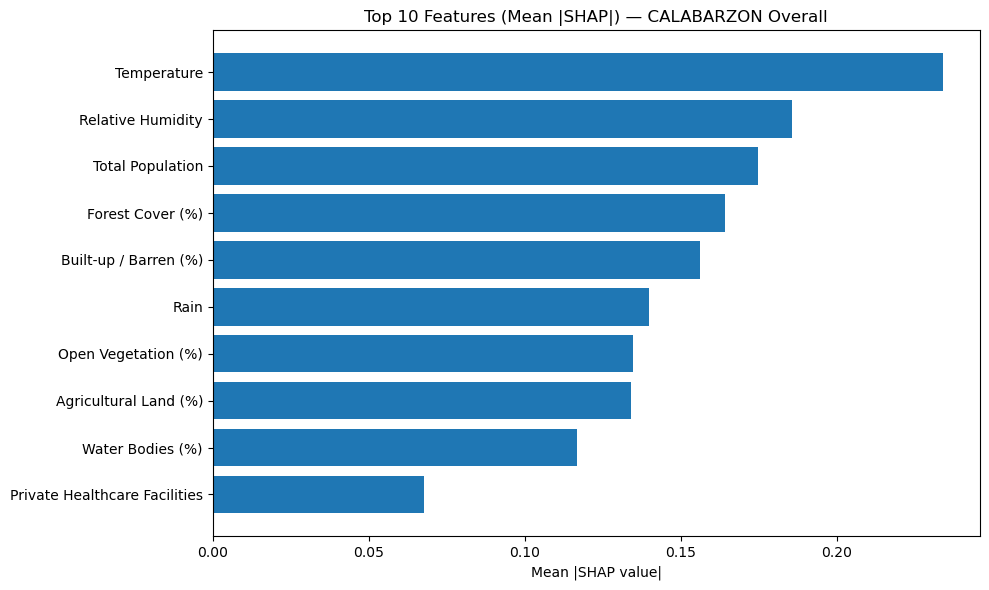


Top 10 Per Group (Mean |SHAP|):
            Group  RankWithinGroup                                    Feature  \
0         Climate                1                                Temperature   
1         Climate                2                          Relative Humidity   
2         Climate                3                                       Rain   
3   Environmental                1                           Forest Cover (%)   
4   Environmental                2                      Built-up / Barren (%)   
5   Environmental                3                        Open Vegetation (%)   
6   Environmental                4                      Agricultural Land (%)   
7   Environmental                5                           Water Bodies (%)   
8   Environmental                6          Flood Hazard Level_LITTLE TO NONE   
9   Environmental                7                     Flood Hazard Level_LOW   
10  Environmental                8                    Flood Hazard Level_HIG

In [77]:
# ============================================================
# SHAP (Shapley) — Overall + By Group (Top 10) [No Month/Year]
# FIXED for multi-class 3D SHAP outputs
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

TOP_N = 10
EXPLAIN_SAMPLE = 2000   # set 500-2000 if slow
RANDOM_STATE = 42

# -----------------------------
# Sample rows for speed
# -----------------------------
if X.shape[0] > EXPLAIN_SAMPLE:
    X_shap = X.sample(EXPLAIN_SAMPLE, random_state=RANDOM_STATE)
else:
    X_shap = X.copy()

# -----------------------------
# Compute SHAP values
# -----------------------------
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# -----------------------------
# Convert SHAP to global importance (mean |SHAP|)
# Handles:
#  - list of arrays: [ (n, f), (n, f), ... ]
#  - 3D array: (n, f, k)
#  - 2D array: (n, f)
# -----------------------------
if isinstance(shap_values, list):
    # list length = num_classes, each (n_samples, n_features)
    abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (n, f)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # (n_samples, n_features, n_classes)
    abs_shap = np.mean(np.abs(shap_values), axis=2)  # (n, f)
else:
    # (n_samples, n_features)
    abs_shap = np.abs(shap_values)

mean_abs_shap = abs_shap.mean(axis=0)  # (f,)

# -----------------------------
# Build SHAP importance table
# -----------------------------
shap_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "MeanAbsSHAP": mean_abs_shap
})

# Remove time variables
shap_df = shap_df[~shap_df["Feature"].isin(["Month", "Year"])].copy()

# -----------------------------
# Assign groups
# -----------------------------
CLIMATE_BASE = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_BASE = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_BASE = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

def assign_group(feature_name: str) -> str:
    if feature_name in CLIMATE_BASE:
        return "Climate"
    if any(feature_name == b or feature_name.startswith(b + "_") for b in SOCIO_BASE):
        return "Socioeconomic"
    if any(feature_name == b or feature_name.startswith(b + "_") for b in ENV_BASE):
        return "Environmental"
    return "Other"

shap_df["Group"] = shap_df["Feature"].apply(assign_group)

# Keep only the 3 groups
shap_df_3 = shap_df[shap_df["Group"].isin(["Climate", "Socioeconomic", "Environmental"])].copy()

# -----------------------------
# Top 10 Overall
# -----------------------------
top10_overall_shap = (
    shap_df_3.sort_values("MeanAbsSHAP", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)
top10_overall_shap["RankOverall"] = np.arange(1, len(top10_overall_shap) + 1)

print("\nTop 10 Overall (Mean |SHAP|) — CALABARZON:")
print(top10_overall_shap[["RankOverall", "Feature", "Group", "MeanAbsSHAP"]])

plt.figure(figsize=(10, 6))
plt.barh(top10_overall_shap["Feature"][::-1], top10_overall_shap["MeanAbsSHAP"][::-1])
plt.title("Top 10 Features (Mean |SHAP|) — CALABARZON Overall")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()

# -----------------------------
# Top 10 Per Group
# -----------------------------
shap_df_3 = shap_df_3.sort_values(["Group", "MeanAbsSHAP"], ascending=[True, False]).reset_index(drop=True)
shap_df_3["RankWithinGroup"] = shap_df_3.groupby("Group")["MeanAbsSHAP"].rank(ascending=False, method="dense").astype(int)

top10_by_group_shap = (
    shap_df_3[shap_df_3["RankWithinGroup"] <= TOP_N]
    .sort_values(["Group", "RankWithinGroup"])
    .reset_index(drop=True)
)

print("\nTop 10 Per Group (Mean |SHAP|):")
print(top10_by_group_shap[["Group", "RankWithinGroup", "Feature", "MeanAbsSHAP"]])

# Optional: save both tables to Excel for dashboard
out_path = "/Users/alexandrasantos/Downloads/SHAP_FeatureImportance_CALABARZON.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
     top10_overall_shap.to_excel(writer, sheet_name="Top10_Overall", index=False)
     top10_by_group_shap.to_excel(writer, sheet_name="Top10_ByGroup", index=False)
print("Saved:", out_path)

In [83]:
EXPLAIN_SAMPLE = 2000
RANDOM_STATE = 42

# remove Month/Year for plotting
DROP_FOR_PLOT = [c for c in ["Month", "Year"] if c in X.columns]

# sample rows
if X.shape[0] > EXPLAIN_SAMPLE:
    X_shap_full = X.sample(EXPLAIN_SAMPLE, random_state=RANDOM_STATE)
else:
    X_shap_full = X.copy()

# drop time variables for visualization
X_shap = X_shap_full.drop(columns=DROP_FOR_PLOT, errors="ignore")

# compute shap values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap_full)

# remove shap values for Month/Year
drop_idx = [X_shap_full.columns.get_loc(c) for c in DROP_FOR_PLOT if c in X_shap_full.columns]

def drop_shap_columns(shap_obj, drop_indices):

    if not drop_indices:
        return shap_obj

    if isinstance(shap_obj, list):
        return [np.delete(sv, drop_indices, axis=1) for sv in shap_obj]

    if isinstance(shap_obj, np.ndarray) and shap_obj.ndim == 3:
        return np.delete(shap_obj, drop_indices, axis=1)

    return np.delete(shap_obj, drop_indices, axis=1)

shap_values_plot = drop_shap_columns(shap_values, drop_idx)

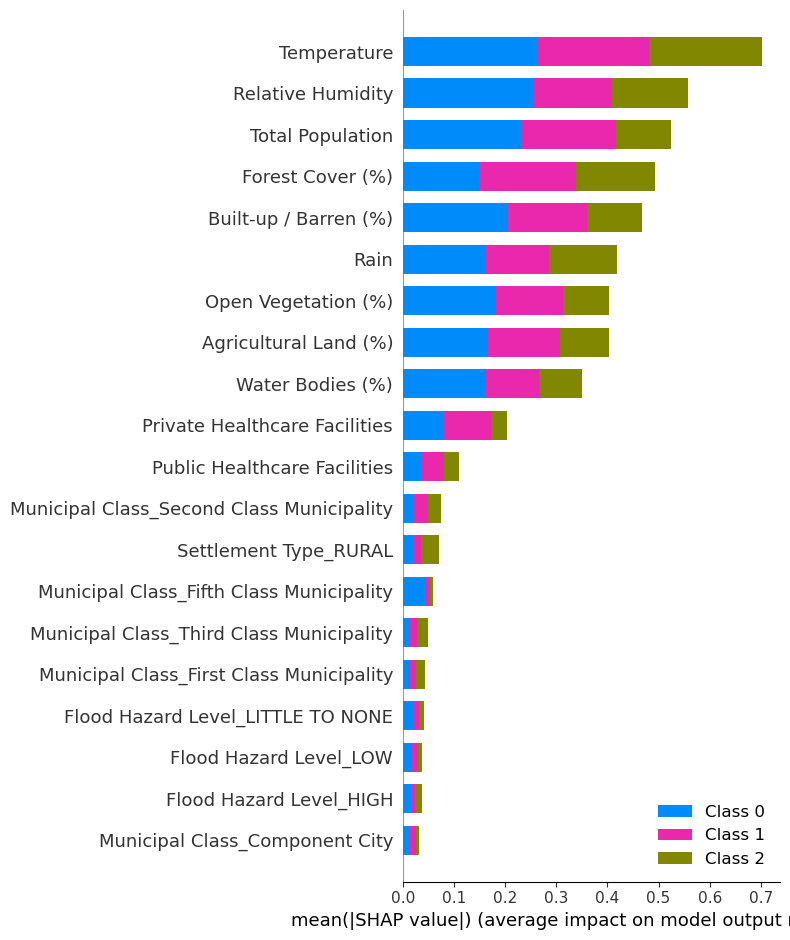

Text(0.5, 1.0, 'SHAP Feature Importance (CALABARZON Dengue Model)')

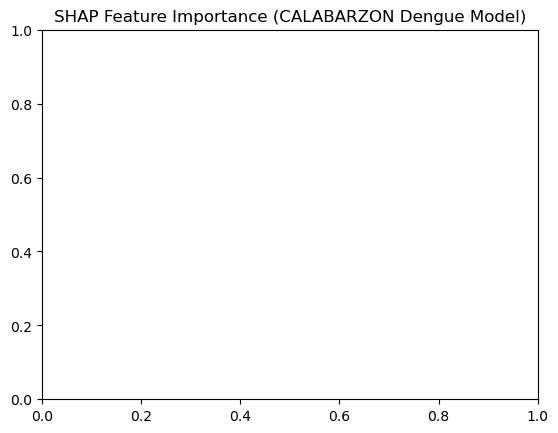

In [85]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values_plot,
    X_shap,
    plot_type="bar",
    show=True
)

plt.title("SHAP Feature Importance (CALABARZON Dengue Model)")

<Figure size 1000x600 with 0 Axes>

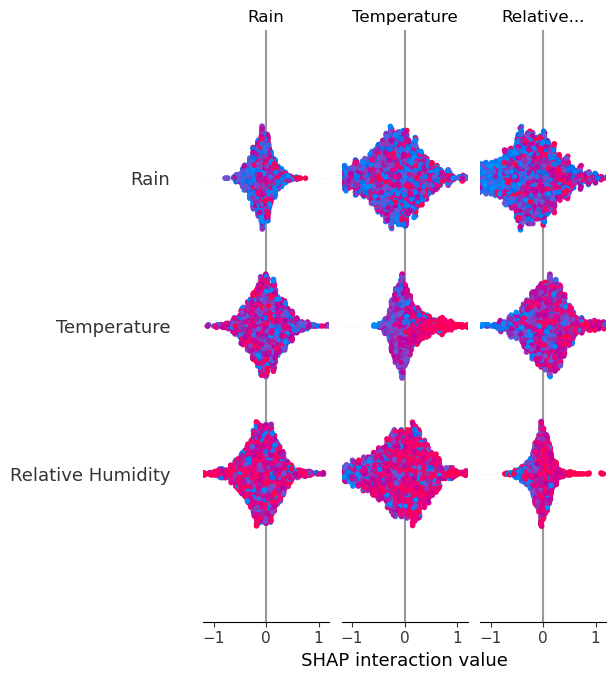

In [87]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values_plot,
    X_shap,
    show=True
)


SHAP explanation for: High


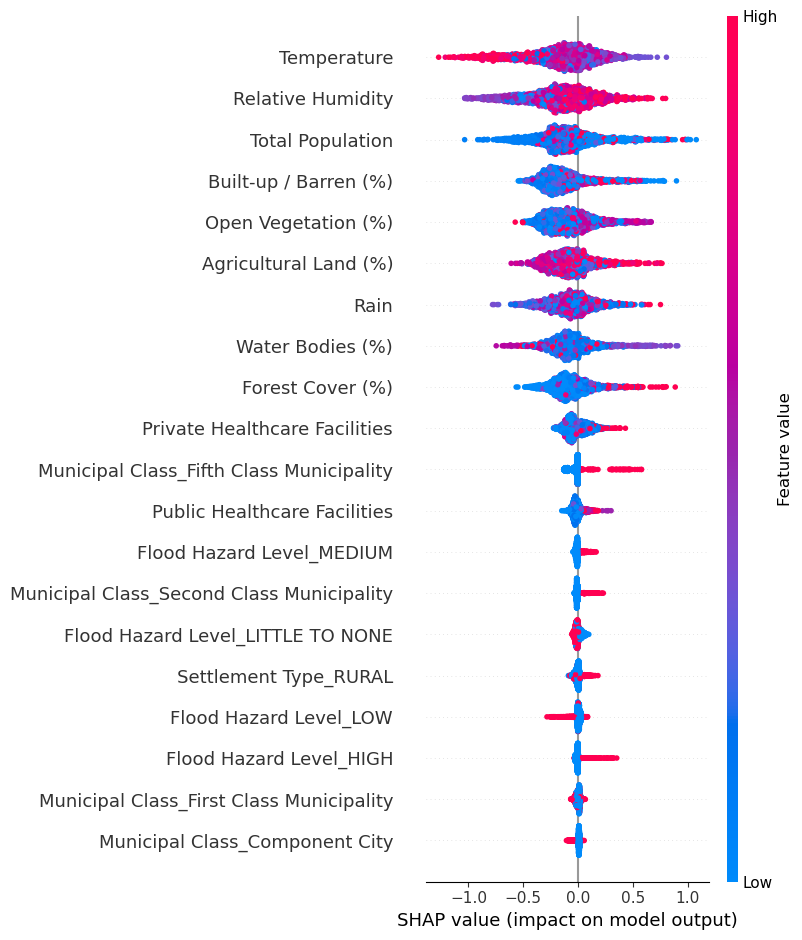


SHAP explanation for: Low


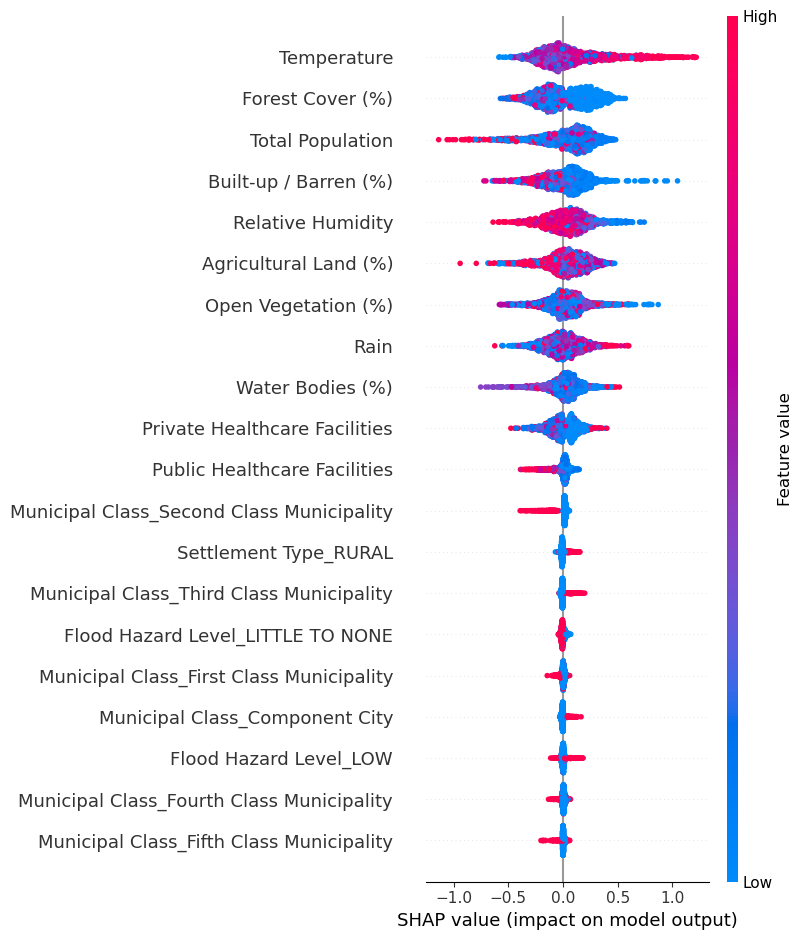


SHAP explanation for: Medium


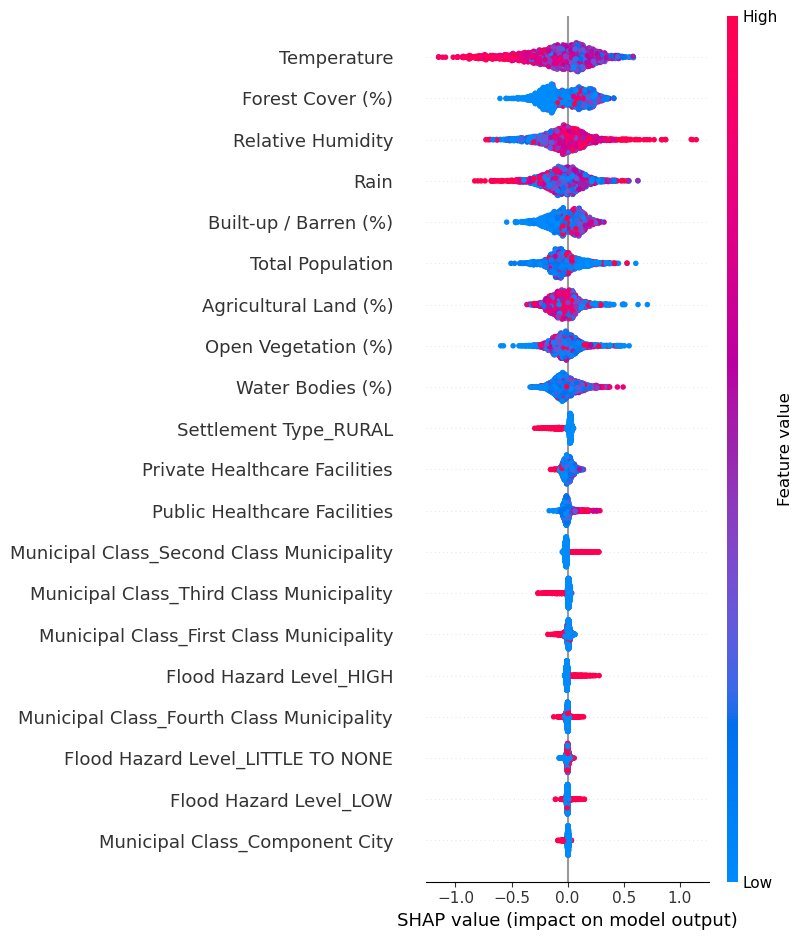

In [89]:
# get class names
class_names = None
try:
    class_names = list(le.classes_)
except:
    pass


if isinstance(shap_values_plot, list):

    for i, sv in enumerate(shap_values_plot):

        cname = class_names[i] if class_names else f"Class {i}"

        print(f"\nSHAP explanation for: {cname}")

        shap.summary_plot(sv, X_shap)


elif isinstance(shap_values_plot, np.ndarray) and shap_values_plot.ndim == 3:

    k = shap_values_plot.shape[2]

    for i in range(k):

        cname = class_names[i] if class_names else f"Class {i}"

        print(f"\nSHAP explanation for: {cname}")

        shap.summary_plot(shap_values_plot[:,:,i], X_shap)